En este notebook se crea una primera clase padre donde se definen atributos (datos) y métodos (funciones) que serán heredadas por los hijos que se irán creando a lo largo del capítulo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

In [ ]:
class IterativeBass():

    def __init__(self, symbol, start, end, amount):
        self.symbol = symbol
        self.start = start
        self.end = end
        self.initial_balance = amount
        self.current_balance = amount
        self.units = 0
        self.trades = 0
        self.get_data()
    
    def get_data(self):
        raw = pd.read_csv("detailed.csv", parse_dates = ['time'], index_col= 'time').dropna()
        raw = raw.loc[self.start:self.end]
        raw['returns'] = np.log(raw.price / raw.price.shift(1))
        self.data = raw

    def plot_data(self, cols = None):
        if cols is None:
            cols = "price"
        self.data[cols].plot(figsize =(12, 8), title = self.symbol)

    def get_values(self, bar):
        date = str(self.data.index[bar].date())
        price = round(self.data.price.iloc[bar], 5)
        spread = round(self.data.spread.iloc[bar], 5)
        return date, price, spread
    
    def print_current_balance(self, bar):
        date, price, spread = self.get_values(bar)
        print("{} | Current Balance: {}".format(date, round(self.current_balance, 2)))

    def buy_instrument(self, bar, units = None, amount = None):
        date, price, spread = self.get_values(bar)
        if amount is not None:
            units = int(amount / price)
        self.current_balance -= units * price
        self.units += units
        self.trades += 1
        print(f"{date} |  Buying {units} for {round(price, 5)}")

    def sell_instrument(self, bar, units = None, amount = None):
        date, price, spread = self.get_values(bar)
        if amount is not None:
            units = int(amount / price)
        self.current_balance += units * price
        self.units -= units
        self.trades += 1
        print(f"{date} |  Selling {units} for {round(price, 5)}")
   

    def print_current_position_value(self, bar):
        date, price, spread = self.get_values(bar)
        cpv = self.units * price
        print("{} | Current Position Value = {}".format(date, round(cpv, 2)))

    def print_current_nav(self, bar):
        date, price, spread = self.get_values(bar)
        nav = self.current_balance + self.units * price
        print("{} | Net Asset Value = {}".format(date, round(nav, 2)))
    

    

In [3]:
bc = IterativeBass("EURUSD", "2006-12-31", "2020-06-30", 100000)

In [4]:
bc.data

,price,spread,returns
time,,,
2006-12-31 22:00:00+00:00,1.31985,0.00100,NaN
2007-01-01 22:00:00+00:00,1.32734,0.00015,0.005659
2007-01-02 22:00:00+00:00,1.31688,0.00015,-0.007912
2007-01-03 22:00:00+00:00,1.30845,0.00015,-0.006422
2007-01-04 22:00:00+00:00,1.30025,0.00100,-0.006287
...,...,...,...
2020-06-23 21:00:00+00:00,1.12507,0.00030,-0.005151
2020-06-24 21:00:00+00:00,1.12180,0.00023,-0.002911
2020-06-25 21:00:00+00:00,1.12184,0.00041,0.000036


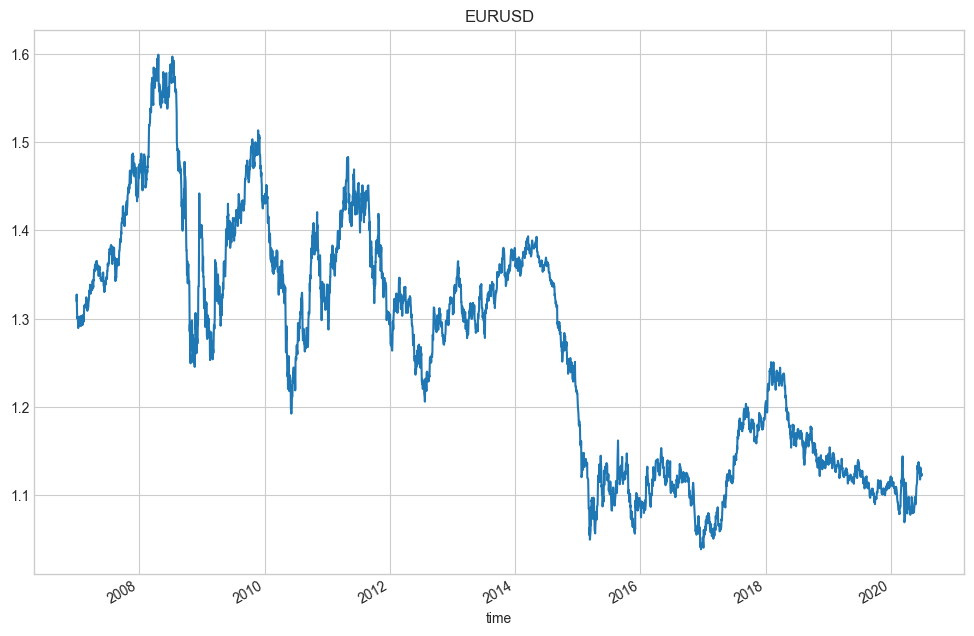

In [5]:
bc.plot_data()

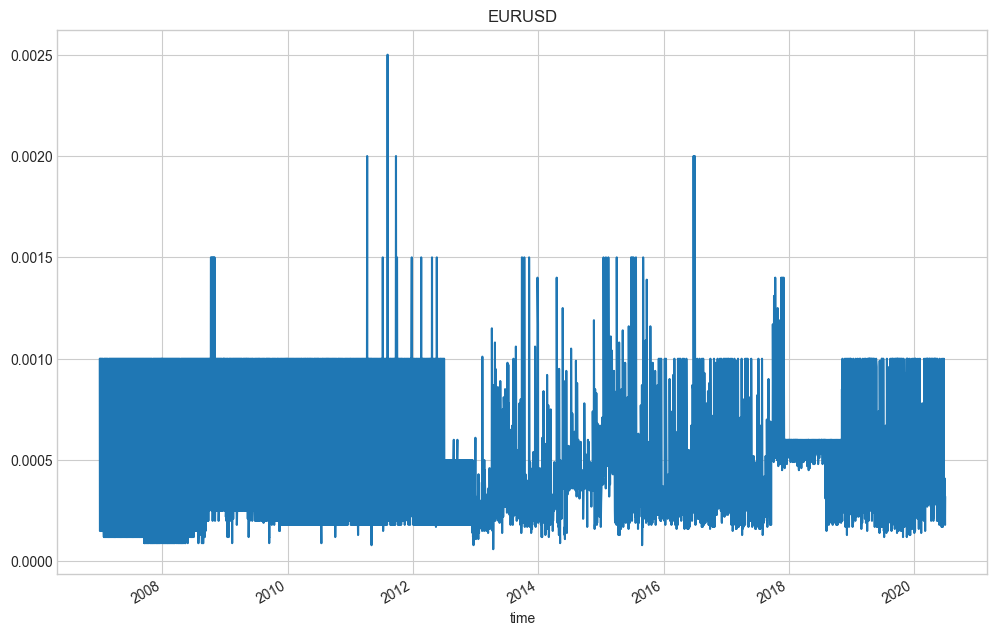

In [6]:
bc.plot_data(cols= 'spread')

In [7]:
# obtener algunos datos con el método get_values
bc.get_values(0)

('2006-12-31', np.float64(1.31985), np.float64(0.001))

In [8]:
bc.get_values(100)

('2007-04-22', np.float64(1.35759), np.float64(0.00012))

In [9]:
bc.get_values(-1)

('2020-06-29', np.float64(1.12331), np.float64(0.00032))

In [10]:
bc.print_current_balance(0)

2006-12-31 | Current Balance: 100000


In [11]:
bc.print_current_balance(100)

2007-04-22 | Current Balance: 100000


In [12]:
bc.buy_instrument(0, units = 1000)

2006-12-31 |  Buying 1000 for 1.31985


In [13]:
bc.print_current_balance(0)

2006-12-31 | Current Balance: 98680.15


In [14]:
bc.buy_instrument(1, amount=5000)

2007-01-01 |  Buying 3766 for 1.32734


In [15]:
int(5000 / 1.32734)

3766

In [16]:
bc.print_current_balance(1)

2007-01-01 | Current Balance: 93681.39


In [17]:
bd = IterativeBass("EURUSD", "2006-12-31", "2020-06-30", 100000)

In [18]:
bd.data

,price,spread,returns
time,,,
2006-12-31 22:00:00+00:00,1.31985,0.00100,NaN
2007-01-01 22:00:00+00:00,1.32734,0.00015,0.005659
2007-01-02 22:00:00+00:00,1.31688,0.00015,-0.007912
2007-01-03 22:00:00+00:00,1.30845,0.00015,-0.006422
2007-01-04 22:00:00+00:00,1.30025,0.00100,-0.006287
...,...,...,...
2020-06-23 21:00:00+00:00,1.12507,0.00030,-0.005151
2020-06-24 21:00:00+00:00,1.12180,0.00023,-0.002911
2020-06-25 21:00:00+00:00,1.12184,0.00041,0.000036


In [19]:
bd.print_current_balance(0)

2006-12-31 | Current Balance: 100000


In [20]:
bd.buy_instrument(0, units= 1000)

2006-12-31 |  Buying 1000 for 1.31985


In [21]:
bd.units

1000

In [22]:
bd.print_current_balance(0)

2006-12-31 | Current Balance: 98680.15


In [23]:
bd.print_current_position_value(0)

2006-12-31 | Current Position Value = 1319.85


In [24]:
bd.print_current_nav(0)

2006-12-31 | Net Asset Value = 100000.0


In [25]:
bd.print_current_position_value(1)

2007-01-01 | Current Position Value = 1327.34


In [26]:
bd.print_current_nav(1)

2007-01-01 | Net Asset Value = 100007.49


In [27]:
bd.buy_instrument(1, amount= 5000)

2007-01-01 |  Buying 3766 for 1.32734


In [37]:
print(bd.units)

4766


In [28]:
bd.print_current_balance(1)

2007-01-01 | Current Balance: 93681.39


In [29]:
bd.print_current_balance(1)

2007-01-01 | Current Balance: 93681.39


In [30]:
bd.print_current_position_value(1)

2007-01-01 | Current Position Value = 6326.1


In [31]:
bd.print_current_nav(1)

2007-01-01 | Net Asset Value = 100007.49


In [32]:
bd.print_current_balance(2)

2007-01-02 | Current Balance: 93681.39


In [39]:
fecha, precio, diferencia = bd.get_values(2)
print("Precio del dia:" , precio)
print("unidades:", bd.units)

Precio del dia: 1.31688
unidades: 4766


In [33]:
bd.print_current_position_value(2)

2007-01-02 | Current Position Value = 6276.25


In [34]:
bd.print_current_nav(2)

2007-01-02 | Net Asset Value = 99957.64


In [40]:
fecha, precio, diferencia = bd.get_values(-1)
print("Precio del dia:" , precio)
print("unidades:", bd.units)

Precio del dia: 1.12331
unidades: 4766


In [41]:
bd.print_current_balance(-1)

2020-06-29 | Current Balance: 93681.39


In [35]:
bd.print_current_nav(-1)

2020-06-29 | Net Asset Value = 99035.08


In [36]:
bd.print_current_position_value(-1)

2020-06-29 | Current Position Value = 5353.7
